# Phase 2 — Random Forest Baseline

This notebook is designed to run as a standalone workflow.
It reads the cleaned combined dataset produced by Phase 1, performs a session-level split, trains a Random Forest baseline model, evaluates validation and test performance, analyzes feature importance and prediction errors, and saves the trained model for reuse.

## Objective

Use the six DSP-derived features from Phase 1 to classify `diam`, `low`, and `high` vibration sessions with a Random Forest baseline model.

This is a reference model only, not the final deployment model.

In [1]:
# Optional dependency installation for environments that do not yet have the required libraries.
# Uncomment the next line if the notebook is running in a fresh environment.
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

RANDOM_STATE = 42
FEATURES = [
    'peak_hz',
    'peak_mg',
    'rms_mg',
    'band_0_5_mg',
    'band_5_15_mg',
    'band_15_30_mg',
]
TARGET = 'class_name'

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
DATASET_PATHS = [
    DATA_DIR / 'vibration_clean_dataset.csv',
    PROJECT_ROOT / 'dataset' / 'vibration_clean_dataset.csv',
    PROJECT_ROOT / 'cleaned_data.csv',
    PROJECT_ROOT / 'combined_dataset.csv',
]

for candidate in DATASET_PATHS:
    if candidate.exists():
        DATASET_PATH = candidate
        break
else:
    DATASET_PATH = DATASET_PATHS[0]

print(f"Project root: {PROJECT_ROOT}")
print(f"Expected dataset path: {DATASET_PATH}")

Project root: /content
Expected dataset path: /content/data/vibration_clean_dataset.csv


In [3]:
# Load the cleaned dataset produced by Phase 1.
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found. Please save the Phase 1 combined dataset to: {DATASET_PATH}"
    )

raw_df = pd.read_csv(DATASET_PATH)
print(f"Loaded dataset from: {DATASET_PATH}")
print(f"Shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

required_cols = FEATURES + [TARGET, 'session_id', 'source_file']
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

raw_df = raw_df[required_cols].copy()
print("Required columns verified.")

Loaded dataset from: /content/data/vibration_clean_dataset.csv
Shape: (900, 20)
Columns: ['label', 'class_name', 'session_id', 'frame', 'start_ms', 'end_ms', 'span_ms', 'hop_ms', 'peak_bin', 'peak_hz', 'peak_mg', 'rms_mg', 'band_0_5_mg', 'band_5_15_mg', 'band_15_30_mg', 'read_err', 'push_err', 'ring_ovf', 'wake_ovf', 'source_file']
Required columns verified.


In [4]:
# Define a unique session identifier for split safety.
# source_file is the most reliable unique session identifier because session_id overlaps across classes.
raw_df['session_key'] = raw_df['class_name'].astype(str) + '_' + raw_df['source_file'].astype(str)

print(raw_df[['class_name', 'session_id', 'source_file', 'session_key']].head())
print(f"Unique sessions: {raw_df['session_key'].nunique()}")

  class_name  session_id source_file      session_key
0       diam           1  diam01.csv  diam_diam01.csv
1       diam           1  diam01.csv  diam_diam01.csv
2       diam           1  diam01.csv  diam_diam01.csv
3       diam           1  diam01.csv  diam_diam01.csv
4       diam           1  diam01.csv  diam_diam01.csv
Unique sessions: 30


## 1. Objective

The goal is to benchmark the six DSP features as a baseline feature set for classifying vibration states on unseen sessions.

## 2. Prepare Dataset

We only keep the features needed for modeling and the target label.

In [5]:
X = raw_df[FEATURES].copy()
y = raw_df[TARGET].copy()

# Keep metadata for split tracking and error analysis.
metadata = raw_df[['source_file', 'session_id', 'class_name', 'session_key']].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class order: {sorted(y.unique())}")

X shape: (900, 6)
y shape: (900,)
Class order: ['diam', 'high', 'low']


## 3. Session-Level Split

This split must be at the session level, not the frame level. Each session belongs to only one split.

In [6]:
# Determine unique sessions by class, then split 6 / 2 / 2 within each class.
train_sessions_by_class = {}
val_sessions_by_class = {}
test_sessions_by_class = {}

for cls in ['diam', 'low', 'high']:
    sessions = sorted(raw_df.loc[raw_df['class_name'] == cls, 'source_file'].unique())
    rng = np.random.RandomState(RANDOM_STATE)
    shuffled = rng.permutation(sessions)
    train_sessions_by_class[cls] = set(shuffled[:6])
    val_sessions_by_class[cls] = set(shuffled[6:8])
    test_sessions_by_class[cls] = set(shuffled[8:10])

train_sessions = set().union(*train_sessions_by_class.values())
val_sessions = set().union(*val_sessions_by_class.values())
test_sessions = set().union(*test_sessions_by_class.values())

assert train_sessions.isdisjoint(val_sessions)
assert train_sessions.isdisjoint(test_sessions)
assert val_sessions.isdisjoint(test_sessions)

train_mask = raw_df['source_file'].isin(train_sessions)
val_mask = raw_df['source_file'].isin(val_sessions)
test_mask = raw_df['source_file'].isin(test_sessions)

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_val = X[val_mask].copy()
y_val = y[val_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

print('Session split summary:')
for cls in ['diam', 'low', 'high']:
    print(
        f"  {cls:>5s} | train={len(train_sessions_by_class[cls])} "
        f"| val={len(val_sessions_by_class[cls])} | test={len(test_sessions_by_class[cls])}"
    )

print(f"Train frames: {len(X_train)}")
print(f"Validation frames: {len(X_val)}")
print(f"Test frames: {len(X_test)}")

split_summary = []
for split_name, sessions_map in {
    'train': train_sessions_by_class,
    'validation': val_sessions_by_class,
    'test': test_sessions_by_class,
}.items():
    for cls, sess in sessions_map.items():
        n_frames = raw_df[(raw_df['class_name'] == cls) & (raw_df['source_file'].isin(sess))].shape[0]
        split_summary.append({
            'Split': split_name,
            'Class': cls,
            'Sessions': len(sess),
            'Frames': n_frames,
        })

split_df = pd.DataFrame(split_summary)
print(split_df.to_string(index=False))

Session split summary:
   diam | train=6 | val=2 | test=2
    low | train=6 | val=2 | test=2
   high | train=6 | val=2 | test=2
Train frames: 540
Validation frames: 180
Test frames: 180
     Split Class  Sessions  Frames
     train  diam         6     180
     train   low         6     180
     train  high         6     180
validation  diam         2      60
validation   low         2      60
validation  high         2      60
      test  diam         2      60
      test   low         2      60
      test  high         2      60


In [9]:
# Quick sanity check: train/val/test sessions must not overlap.
all_sessions = raw_df['source_file'].drop_duplicates().tolist()
train_session_list = sorted(train_sessions)
val_session_list = sorted(val_sessions)
test_session_list = sorted(test_sessions)

print(f"Train sessions total: {len(train_session_list)}")
print(f"Validation sessions total: {len(val_session_list)}")
print(f"Test sessions total: {len(test_session_list)}")
print(f"All unique sessions: {len(all_sessions)}")

assert len(train_session_list) == 18
assert len(val_session_list) == 6
assert len(test_session_list) == 6

Train sessions total: 18
Validation sessions total: 6
Test sessions total: 6
All unique sessions: 30


## 4. Train Random Forest

Use a simple, reproducible Random Forest baseline model without tuning.

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Random Forest baseline trained successfully.")

Random Forest baseline trained successfully.


## 5. Validation Evaluation

Validation is used to monitor performance during development.

In [11]:
val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_pred)
val_precision = precision_score(y_val, val_pred, average='macro', zero_division=0)
val_recall = recall_score(y_val, val_pred, average='macro', zero_division=0)
val_f1 = f1_score(y_val, val_pred, average='macro', zero_division=0)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Macro Precision: {val_precision:.4f}")
print(f"Validation Macro Recall: {val_recall:.4f}")
print(f"Validation Macro F1: {val_f1:.4f}")
print('\nClassification report (Validation):')
print(classification_report(y_val, val_pred, target_names=['diam', 'low', 'high']))

Validation Accuracy: 1.0000
Validation Macro Precision: 1.0000
Validation Macro Recall: 1.0000
Validation Macro F1: 1.0000

Classification report (Validation):
              precision    recall  f1-score   support

        diam       1.00      1.00      1.00        60
         low       1.00      1.00      1.00        60
        high       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## 6. Test Evaluation

Test performance is the final evaluation and must not be used for tuning.

In [12]:
test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, test_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_test, test_pred, average='macro', zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall: {test_recall:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print('\nClassification report (Test):')
print(classification_report(y_test, test_pred, target_names=['diam', 'low', 'high']))

Test Accuracy: 0.9889
Test Macro Precision: 0.9892
Test Macro Recall: 0.9889
Test Macro F1: 0.9889

Classification report (Test):
              precision    recall  f1-score   support

        diam       1.00      1.00      1.00        60
         low       0.97      1.00      0.98        60
        high       1.00      0.97      0.98        60

    accuracy                           0.99       180
   macro avg       0.99      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180



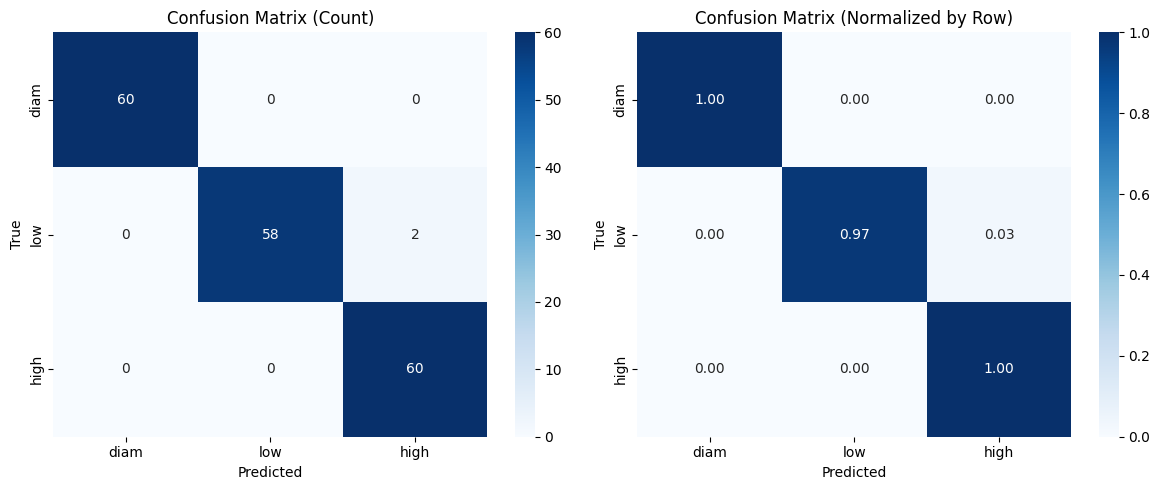

In [13]:
# Confusion matrix for test set (raw counts and normalized values)
labels = ['diam', 'low', 'high']
cm_raw = confusion_matrix(y_test, test_pred, labels=labels)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized by Row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 7. Feature Importance

Random Forest provides a built-in measure of feature importance. This is for model interpretation only; no feature selection decisions are made here.

      Feature  Importance
 band_5_15_mg    0.266481
       rms_mg    0.247380
band_15_30_mg    0.232035
      peak_mg    0.166184
      peak_hz    0.052597
  band_0_5_mg    0.035324


/tmp/ipykernel_13133/1935088535.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


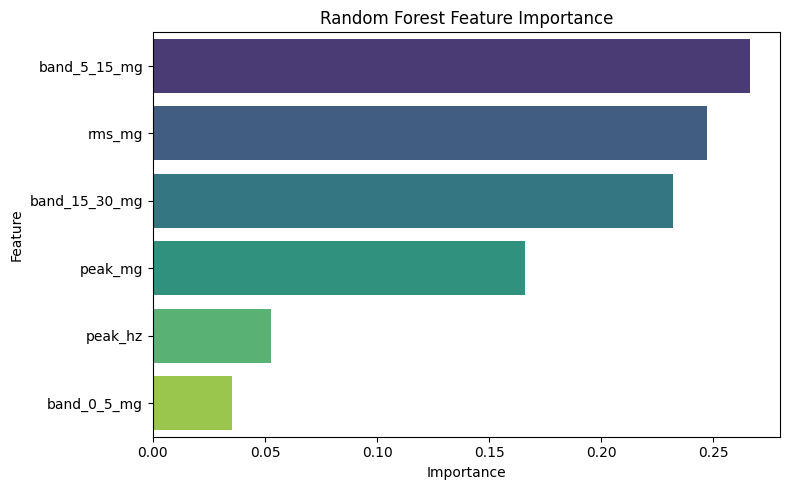

In [14]:
feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(feature_importance.to_string(index=False))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Error Analysis

Inspect the incorrect predictions on the test set to understand the most common confusion pairs.

In [15]:
# Create a test-set prediction dataframe with the required columns.
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
test_pred_reset = pd.Series(test_pred, name='predicted_class')

errors_df = pd.DataFrame({
    'source_file': raw_df.loc[test_mask, 'source_file'].reset_index(drop=True).values,
    'session_id': raw_df.loc[test_mask, 'session_id'].reset_index(drop=True).values,
    'frame': raw_df.loc[test_mask, 'frame'].reset_index(drop=True).values if 'frame' in raw_df.columns else np.arange(len(X_test_reset)),
    'true_class': y_test_reset.values,
    'predicted_class': test_pred_reset.values,
})

for feature in FEATURES:
    errors_df[feature] = X_test_reset[feature].values

errors_df = errors_df[errors_df['true_class'] != errors_df['predicted_class']].copy()
errors_df['error_pair'] = errors_df['true_class'] + ' -> ' + errors_df['predicted_class']

print(f"Total misclassified test samples: {len(errors_df)}")
print(errors_df[['source_file', 'session_id', 'frame', 'true_class', 'predicted_class', *FEATURES]].head(20).to_string(index=False))

error_counts = errors_df['error_pair'].value_counts().sort_values(ascending=False)
print('\nMost common confusion pairs:')
print(error_counts.to_string())

Total misclassified test samples: 2
source_file  session_id  frame true_class predicted_class  peak_hz  peak_mg  rms_mg  band_0_5_mg  band_5_15_mg  band_15_30_mg
  low07.csv           7    104        low            high   11.328        3       8            3             5              4
  low07.csv           7    119        low            high   31.250        2       6            2             3              3

Most common confusion pairs:
error_pair
low -> high    2


In [16]:
# Session-level performance on the test set.
source_file_to_true = raw_df.loc[test_mask, ['source_file', 'class_name']].drop_duplicates().set_index('source_file')['class_name']

test_session_summary = []
for session in sorted(test_sessions):
    session_mask = (raw_df['source_file'] == session) & test_mask
    session_df = raw_df[session_mask].copy()
    session_true = session_df['class_name'].values
    session_pred = model.predict(session_df[FEATURES].values)
    correct = np.sum(session_true == session_pred)
    accuracy = correct / len(session_df)
    test_session_summary.append({
        'Session': session,
        'Class': session_df['class_name'].iloc[0],
        'Frames': len(session_df),
        'Correct': int(correct),
        'Accuracy': float(accuracy),
    })

session_perf_df = pd.DataFrame(test_session_summary).sort_values('Accuracy')
print(session_perf_df.to_string(index=False))

worst_session = session_perf_df.iloc[0]
print(f"\nWorst-performing test session: {worst_session['Session']} | Accuracy={worst_session['Accuracy']:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

   Session Class  Frames  Correct  Accuracy
 low07.csv   low      30       28  0.933333
diam04.csv  diam      30       30  1.000000
high04.csv  high      30       30  1.000000
diam07.csv  diam      30       30  1.000000
high07.csv  high      30       30  1.000000
 low04.csv   low      30       30  1.000000

Worst-performing test session: low07.csv | Accuracy=0.9333


## 9. Save Model

Persist the trained model and metadata so the model can be reused or compared against future models.

In [17]:
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True, parents=True)

model_path = MODEL_DIR / 'random_forest_baseline.pkl'
metadata_path = MODEL_DIR / 'random_forest_baseline_metadata.json'

joblib.dump(model, model_path)

metadata = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': 100,
    'random_state': RANDOM_STATE,
    'features': FEATURES,
    'target': TARGET,
    'classes': ['diam', 'low', 'high'],
    'validation_accuracy': float(val_accuracy),
    'validation_macro_f1': float(val_f1),
    'test_accuracy': float(test_accuracy),
    'test_macro_f1': float(test_f1),
    'split_sessions': {
        'train': sorted(train_sessions),
        'validation': sorted(val_sessions),
        'test': sorted(test_sessions),
    },
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")

Model saved to: /content/models/random_forest_baseline.pkl
Metadata saved to: /content/models/random_forest_baseline_metadata.json


## 10. Summary & Next Step

In [21]:
print("\n" + "="*100)
print("PHASE 2 RANDOM FOREST BASELINE — EXECUTION SUMMARY")
print("="*100)

print("\n" + "-"*100)
print("1. WHAT WAS DONE IN PHASE 2")
print("-"*100)
print(f"""
✓ Loaded the cleaned dataset from: {DATASET_PATH}
✓ Kept the 6 DSP features used for modeling: {', '.join(FEATURES)}
✓ Performed a session-level split with 18 train sessions, 6 validation sessions, and 6 test sessions
✓ Trained a RandomForestClassifier with 100 estimators and random_state={RANDOM_STATE}
✓ Evaluated validation and test performance
✓ Analyzed feature importance and prediction errors
✓ Saved the trained model to: {MODEL_DIR / 'random_forest_baseline.pkl'}
✓ Saved model metadata to: {MODEL_DIR / 'random_forest_baseline_metadata.json'}
""")

print("\n" + "-"*100)
print("2. ACTUAL RESULTS")
print("-"*100)
print(f"""
✓ Validation Accuracy:   {val_accuracy:.4f}
✓ Validation Macro F1:   {val_f1:.4f}
✓ Test Accuracy:         {test_accuracy:.4f}
✓ Test Macro F1:         {test_f1:.4f}
""")

print("\n" + "-"*100)
print("3. FEATURE IMPORTANCE & ERROR ANALYSIS")
print("-"*100)
print(f"""
✓ Top feature by importance: {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})
✓ Worst-performing test session: {worst_session['Session']} (accuracy={worst_session['Accuracy']:.4f})
""")

if len(errors_df) > 0:
    print(f"✓ Most common confusion pair: {error_counts.index[0]} ({error_counts.iloc[0]} samples)")
else:
    print("✓ Most common confusion pair: no misclassifications on the test set")

print("\n" + "-"*100)
print("4. PHASE 3 NEXT STEP")
print("-"*100)
print("""
✓ The Phase 2 output is a Random Forest baseline reference model for the six DSP features.
✓ The next step is to build a compact neural network (MLP) for TinyML deployment and compare it against this baseline.
""")
print("\n" + "="*100)


PHASE 2 RANDOM FOREST BASELINE — EXECUTION SUMMARY

----------------------------------------------------------------------------------------------------
1. WHAT WAS DONE IN PHASE 2
----------------------------------------------------------------------------------------------------

✓ Loaded the cleaned dataset from: /content/data/vibration_clean_dataset.csv
✓ Kept the 6 DSP features used for modeling: peak_hz, peak_mg, rms_mg, band_0_5_mg, band_5_15_mg, band_15_30_mg
✓ Performed a session-level split with 18 train sessions, 6 validation sessions, and 6 test sessions
✓ Trained a RandomForestClassifier with 100 estimators and random_state=42
✓ Evaluated validation and test performance
✓ Analyzed feature importance and prediction errors
✓ Saved the trained model to: /content/models/random_forest_baseline.pkl
✓ Saved model metadata to: /content/models/random_forest_baseline_metadata.json


----------------------------------------------------------------------------------------------------